In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/news.db")

df = pd.read_sql_query("SELECT title FROM news", conn)

print("Total data:", len(df))
df.head()

Total data: 1345


,title
0,"Trump Nyinyir Lagi: Tolong Beritahu Paus Leo, ..."
1,"AS Kirim Kapal Perang ke Selat Hormuz, Eks KSA..."
2,"Prabowo Bertemu Macron di Istana Elysee, Bahas..."
3,Isi Chat Pelecehan Seksual 16 Mahasiswa Hukum ...
4,"7 Keunggulan Oghab 44, Bandara Bawah Tanah Ira..."


## 🧹 Data Cleaning

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.utils import clean_text, filter_short_words

# Daftar stopword bahasa Indonesia sederhana
stopwords = set(['yang', 'di', 'ke', 'dan', 'dari', 'untuk', 'pada', 'dengan', 'ini', 'itu', 'juga', 'dalam', 'akan', 'oleh', 'ada', 'tidak', 'bisa', 'saat', 'telah', 'atau'])

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stopwords])

# Proses Data Cleaning
df['cleaned_title'] = df['title'].apply(clean_text)
df['cleaned_title'] = df['cleaned_title'].apply(remove_stopwords)
df['cleaned_title'] = df['cleaned_title'].apply(filter_short_words)

print("Hasil Data Cleaning:")
df[['title', 'cleaned_title']].head()

Hasil Data Cleaning:


,title,cleaned_title
0,"Trump Nyinyir Lagi: Tolong Beritahu Paus Leo, ...",trump nyinyir lagi tolong beritahu paus iran b...
1,"AS Kirim Kapal Perang ke Selat Hormuz, Eks KSA...",kirim kapal perang selat hormuz ksal ungkap an...
2,"Prabowo Bertemu Macron di Istana Elysee, Bahas...",prabowo bertemu macron istana elysee bahas alu...
3,Isi Chat Pelecehan Seksual 16 Mahasiswa Hukum ...,chat pelecehan seksual mahasiswa hukum terungk...
4,"7 Keunggulan Oghab 44, Bandara Bawah Tanah Ira...",keunggulan oghab bandara bawah tanah iran ters...


## 📊 Analisis Data & Visualisasi

10 Keyword Teratas: [('indonesia', 255), ('iran', 107), ('kompas', 89), ('detiknews', 81), ('jadi', 63), ('cnbc', 56), ('trump', 52), ('hingga', 52), ('soal', 45), ('harga', 45)]


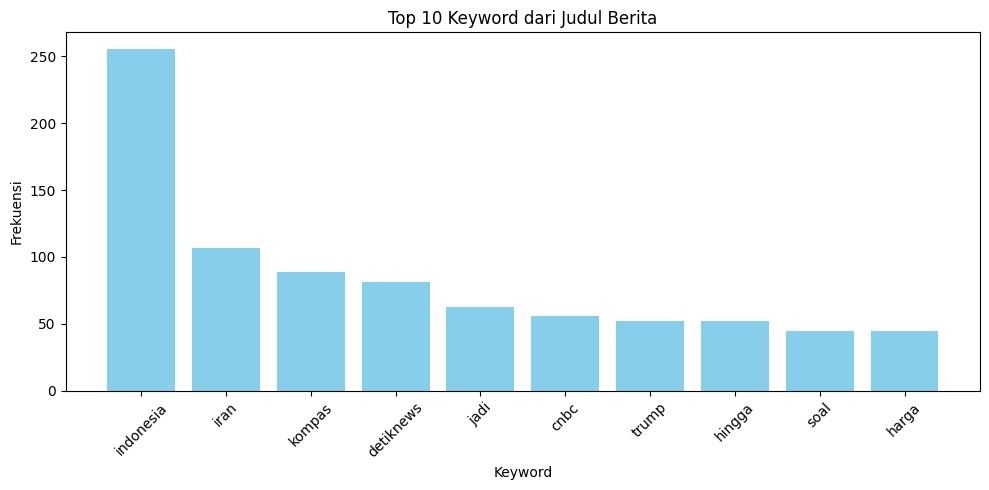

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

# Gabungkan semua kata menjadi satu teks besar
all_words = " ".join(df['cleaned_title'].tolist()).split()

# Hitung frekuensi masing-masing kata
word_counts = Counter(all_words)
top_10 = word_counts.most_common(10)

print("10 Keyword Teratas:", top_10)

# Visualisasi dengan Bar Chart
labels, values = zip(*top_10)

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='skyblue')
plt.title('Top 10 Keyword dari Judul Berita')
plt.xlabel('Keyword')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📈 Analisis Tren Berita Seiring Waktu
Karena topik berfokus pada **Tren Berita**, kita akan melihat bagaimana kata kunci populer naik/turun setiap harinya.

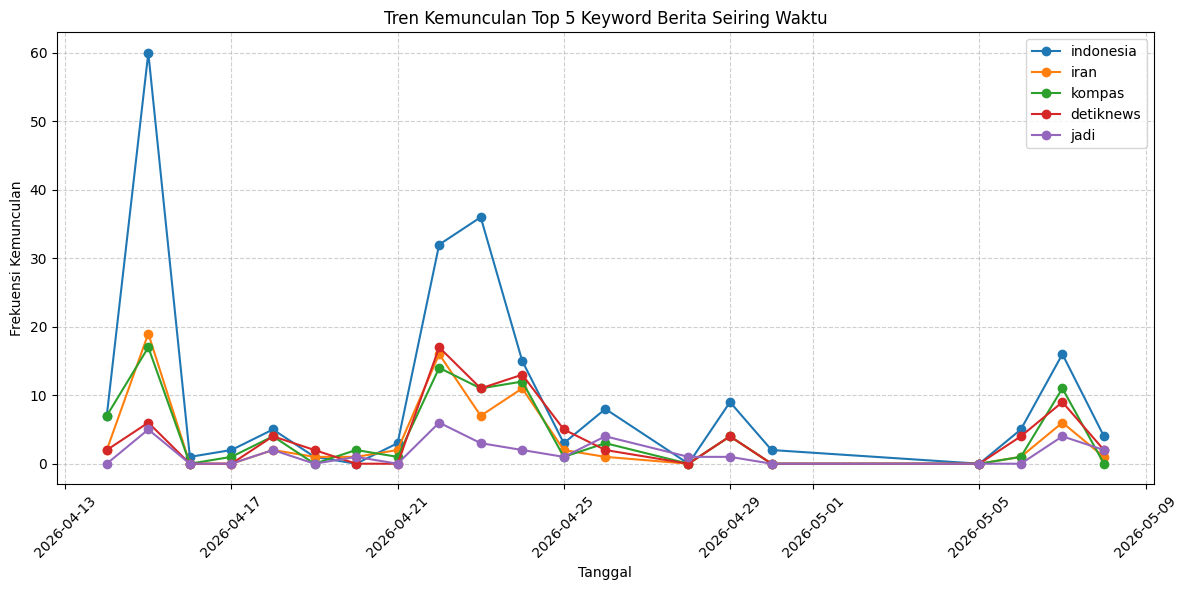

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ambil data beserta tanggalnya
df_trend = pd.read_sql_query("SELECT title, tanggal FROM news", conn)

# 2. Konversi kolom tanggal menjadi tipe datetime dan ambil hanya Tanggal-nya (Y-M-D)
df_trend['tanggal'] = pd.to_datetime(df_trend['tanggal'], errors='coerce')
df_trend['date'] = df_trend['tanggal'].dt.date

# 3. Lakukan proses cleaning yang sama pada df_trend
df_trend['cleaned_title'] = df_trend['title'].apply(clean_text)
df_trend['cleaned_title'] = df_trend['cleaned_title'].apply(remove_stopwords)
df_trend['cleaned_title'] = df_trend['cleaned_title'].apply(filter_short_words)

# 4. Ambil 5 Keyword paling populer dari keseluruhan data
top_5_keywords = [word for word, count in top_10[:5]]

# 5. Siapkan data untuk trend: hitung kemunculan tiap keyword per hari
trend_data = {kw: [] for kw in top_5_keywords}
dates = sorted(df_trend['date'].dropna().unique())

for d in dates:
    text_on_date = " ".join(df_trend[df_trend['date'] == d]['cleaned_title'].tolist()).split()
    for kw in top_5_keywords:
        trend_data[kw].append(text_on_date.count(kw))

# 6. Plotting Trend Line Chart
plt.figure(figsize=(12, 6))
for kw in top_5_keywords:
    plt.plot(dates, trend_data[kw], marker='o', label=kw)

plt.title('Tren Kemunculan Top 5 Keyword Berita Seiring Waktu')
plt.xlabel('Tanggal')
plt.ylabel('Frekuensi Kemunculan')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 🚨 Prototipe Sistem Peringatan Dini (Deteksi Anomali)
Bagian ini mensimulasikan sistem *Early Warning*, di mana kita mencari hari-hari di mana sebuah isu secara tiba-tiba meledak di media massa.

In [5]:
import pandas as pd

# Membuat DataFrame khusus dari data tren sebelumnya
# Indeksnya adalah tanggal, kolomnya adalah keyword
df_anomaly = pd.DataFrame(trend_data, index=dates)

print("Deteksi Anomali (Lonjakan Isu Berita):")
print("-" * 50)

# Kita akan mencari lonjakan tajam (kenaikan > 10 berita dalam 1 hari)
threshold_lonjakan = 10

# Menghitung selisih (kenaikan/penurunan) dengan hari sebelumnya
df_diff = df_anomaly.diff().fillna(0)

anomali_ditemukan = False

for kw in df_diff.columns:
    for date, diff_value in df_diff[kw].items():
        if diff_value >= threshold_lonjakan:
            anomali_ditemukan = True
            # Hitung total berita di hari itu untuk keyword tersebut
            total_hari_itu = df_anomaly.at[date, kw]
            print(f"🚨 ALERT: Lonjakan tajam pada kata kunci '{kw.upper()}' pada tanggal {date}!")
            print(f"   Terjadi peningkatan sebanyak +{int(diff_value)} berita dibanding hari sebelumnya.")
            print(f"   Total berita terkait '{kw}' di hari itu mencapai {total_hari_itu} berita.\n")

if not anomali_ditemukan:
    print("Tidak ada lonjakan berita yang signifikan (melewati threshold).")

# Tampilkan tabel perubahannya agar terlihat angkanya
print("Tabel Kenaikan/Penurunan Harian:")
df_diff.head(10)

Deteksi Anomali (Lonjakan Isu Berita):
--------------------------------------------------
🚨 ALERT: Lonjakan tajam pada kata kunci 'INDONESIA' pada tanggal 2026-04-15!
   Terjadi peningkatan sebanyak +53 berita dibanding hari sebelumnya.
   Total berita terkait 'indonesia' di hari itu mencapai 60 berita.

🚨 ALERT: Lonjakan tajam pada kata kunci 'INDONESIA' pada tanggal 2026-04-22!
   Terjadi peningkatan sebanyak +29 berita dibanding hari sebelumnya.
   Total berita terkait 'indonesia' di hari itu mencapai 32 berita.

🚨 ALERT: Lonjakan tajam pada kata kunci 'INDONESIA' pada tanggal 2026-05-07!
   Terjadi peningkatan sebanyak +11 berita dibanding hari sebelumnya.
   Total berita terkait 'indonesia' di hari itu mencapai 16 berita.

🚨 ALERT: Lonjakan tajam pada kata kunci 'IRAN' pada tanggal 2026-04-15!
   Terjadi peningkatan sebanyak +17 berita dibanding hari sebelumnya.
   Total berita terkait 'iran' di hari itu mencapai 19 berita.

🚨 ALERT: Lonjakan tajam pada kata kunci 'IRAN' pada tang

,indonesia,iran,kompas,detiknews,jadi
2026-04-14,0.0,0.0,0.0,0.0,0.0
2026-04-15,53.0,17.0,10.0,4.0,5.0
2026-04-16,-59.0,-19.0,-17.0,-6.0,-5.0
2026-04-17,1.0,0.0,1.0,0.0,0.0
2026-04-18,3.0,2.0,3.0,4.0,2.0
2026-04-19,-4.0,-1.0,-4.0,-2.0,-2.0
2026-04-20,-1.0,0.0,2.0,-2.0,1.0
2026-04-21,3.0,1.0,-1.0,0.0,-1.0
2026-04-22,29.0,14.0,13.0,17.0,6.0
2026-04-23,4.0,-9.0,-3.0,-6.0,-3.0
